# Dataset audit — arithmetic & logical checks

**Dataset:** `data/<DATASET>/raw/` · **Role:** the *only* writer of `data/<DATASET>/manifest/`.

This notebook measures. It does not judge.

Everything here is arithmetic or logical: counts, hashes, geometry, distances, and checks that the
numbers tie out. Anything requiring a human to look at a glyph and decide — what character a class
is, whether two near-identical images are really the same sample, which label wins when one image
carries two — belongs in the companion Marimo notebook, `02_visual_check.py`.

> **Notebook 1 owns derived data. Marimo owns human decisions.**
> Decisions come back as small files under `configs/`, which this notebook reads on its next run.

### Ground rules

- `raw/` is **read-only**. Nothing is renamed, moved, deleted, or rewritten.
- **No semantic labels.** Classes are bare folder IDs. The Thai character mapping is Marimo's job.
- **No thresholds are chosen here.** Near-duplicate *candidates* are computed exhaustively and
  reported as full distributions; where to cut is a judgement made against pixels, not a constant.
- **Nothing is dropped.** Problems are surfaced as flags and findings tables, never silently filtered.
- Deterministic: fixed seed, sorted file order, stable group IDs.

## 1 · Configuration

In [1]:
import hashlib
import json
import platform
import time
from datetime import UTC, datetime
from pathlib import Path

import imagehash
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from scipy import ndimage

DATASET     = "baseline"          # the one knob: a sibling dataset drops in unchanged
APPLY_CROSS_CLASS_RULINGS = True   # False -> skip §6b, class_folder stays exactly as scanned
RANDOM_STATE = 42
SCAN_VERSION = 5                  # bump when sec 4 changes what it records; invalidates the cache

ROOT     = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW      = ROOT / "data" / DATASET / "raw"
MANIFEST = ROOT / "data" / DATASET / "manifest"
CACHE    = ROOT / "data" / DATASET / "cache"
CONFIGS  = ROOT / "configs"           # human decisions, written by 02_visual_check.py
MANIFEST.mkdir(parents=True, exist_ok=True)
(MANIFEST / "pairs").mkdir(exist_ok=True)
CACHE.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
PIXEL_GRID = 16      # images are letterboxed to 16x16

# The raw crops are already trimmed to their own ink by construction (see §4), so a crop that is
# nearly all background, or one whose ink splits into more than one blob, is a property of the raw
# file itself -- not something this pipeline introduces. Measuring it here is filtering, not repair.
INK_THRESHOLD = 200             # grayscale value below which a pixel counts as ink (corpus is white-paper/black-ink)
MIN_INK_COMPONENT_FRAC = 0.002  # ink components smaller than this fraction of the image are scan speckle, not a stroke

# How much of each near-duplicate candidate table to keep on disk. These are NOT decision
# thresholds -- they only bound the file size. The full distributions are reported regardless.
PHASH_PAIR_CUT = 4       # keep pHash pairs with Hamming distance <= 4
PIXEL_PAIR_CUT = 32.0    # keep pixel pairs with RMS gray distance <= 32

np.random.seed(RANDOM_STATE)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 50)

TIMINGS, CHECKS = {}, []

print(f"dataset  : {DATASET}")
print(f"raw      : {RAW}   exists={RAW.exists()}")
print(f"manifest : {MANIFEST}")
assert RAW.exists(), f"{RAW} not found"

dataset  : baseline
raw      : /mnt/srv/home/whats/cnn/repo/data/baseline/raw   exists=True
manifest : /mnt/srv/home/whats/cnn/repo/data/baseline/manifest


## 2 · Filesystem discovery

**What:** enumerate every directory under `raw/` and record which class-ID folders exist.

**Why:** the folder names are the ground-truth class IDs. We must never assume which ones are
present — gaps and surprises have to be observed, not presumed.

**What this does not claim:** a gap in the numeric sequence is *recorded*, not judged. It is not an
error and it is not evidence of anything on its own.

In [2]:
folders = sorted(p for p in RAW.iterdir() if p.is_dir())
rows = []
for p in folders:
    n_img = sum(1 for c in p.iterdir()
                if c.is_file() and c.suffix.lower() in IMAGE_EXTS and not c.name.startswith("."))
    rows.append(dict(folder_name=p.name,
                     class_folder=int(p.name) if p.name.isdigit() else -1,
                     is_numeric=p.name.isdigit(),
                     n_images=n_img,
                     is_empty=not any(p.iterdir())))
folder_inventory = pd.DataFrame(rows).sort_values(["is_numeric", "class_folder"],
                                                  ascending=[False, True]).reset_index(drop=True)

present = sorted(folder_inventory.loc[folder_inventory.is_numeric, "class_folder"])
span    = range(min(present), max(present) + 1)
absent  = [i for i in span if i not in set(present)]

print(f"class folders present : {len(present)}")
print(f"numeric span          : {min(present)}-{max(present)} ({len(span)} ids)")
print(f"absent within span    : {len(absent)} -> {absent}")
print(f"non-numeric folders   : {folder_inventory.loc[~folder_inventory.is_numeric, 'folder_name'].tolist() or 'none'}")
print(f"empty folders         : {folder_inventory.loc[folder_inventory.is_empty, 'folder_name'].tolist() or 'none'}")
folder_inventory.head()

class folders present : 72
numeric span          : 161-249 (89 ids)
absent within span    : 17 -> [165, 166, 172, 174, 198, 208, 211, 218, 219, 220, 221, 222, 223, 235, 237, 238, 239]
non-numeric folders   : none
empty folders         : none


,folder_name,class_folder,is_numeric,n_images,is_empty
0,161,161,True,1951,False
1,162,162,True,1355,False
2,163,163,True,1,False
3,164,164,True,1448,False
4,167,167,True,1078,False


## 3 · File inventory

**What:** classify every file under `raw/` as a usable image, a hidden file, a zero-byte file, or an
unsupported extension.

**Why:** stray files (`Thumbs.db`, `.DS_Store`) inflate naive `ls | wc -l` counts and crash image
loaders. They are reported explicitly so no count is ever quietly wrong.

In [3]:
image_files, non_image_rows = [], []
for p in sorted(RAW.rglob("*")):
    if not p.is_file():
        continue
    size, hidden = p.stat().st_size, p.name.startswith(".")
    if p.suffix.lower() in IMAGE_EXTS and not hidden and size > 0:
        image_files.append(p)
    else:
        non_image_rows.append(dict(
            path=p.relative_to(RAW).as_posix(), name=p.name,
            ext=p.suffix.lower() or "(none)", size_bytes=size,
            reason="hidden" if hidden else "zero-byte" if size == 0 else "unsupported-extension"))

non_images = pd.DataFrame(non_image_rows)
n_files = len(image_files) + len(non_images)
print(f"files under raw/ : {n_files:,}")
print(f"  images         : {len(image_files):,}")
print(f"  non-images     : {len(non_images):,}")
non_images

files under raw/ : 62,711
  images         : 62,707
  non-images     : 4


,path,name,ext,size_bytes,reason
0,.DS_Store,.DS_Store,(none),14340,hidden
1,161/.DS_Store,.DS_Store,(none),159748,hidden
2,161/Thumbs.db,Thumbs.db,.db,147968,unsupported-extension
3,249/Thumbs.db,Thumbs.db,.db,12800,unsupported-extension


## 4 · Single-pass scan

**What:** open each image exactly once and record geometry, colour mode, intensity statistics, a
**SHA-256** of the file bytes, a **pHash**, an ink-coverage measure, and a 16×16 downsample used by
§10.

**Why:** one decode pass feeds every later section. Reading the corpus repeatedly is both slow and a
source of inconsistency between sections.

The result is cached. The cache key is a content signature over `raw/` (file count, total bytes,
newest mtime) plus `SCAN_VERSION`, so it invalidates itself both when the data changes and when this
section changes what it records — there is no manual "use cache" flag to forget to flip.

### Image Preprocessing Notes

All images should be rendered be letterboxed (scale-to-fit, aspect preserved) to a given size (16),
and padded background with white consistently.

**Why letterbox, not stretch:** a plain square stretch distorts exactly the aspect-ratio cues
that separate some classes (า vs ๅ, the ฤ/ป/ไ tails) and would make the distance unfair between
images of different native aspect ratio.

**Why padded white, not a per-image background guess:** every image here is already trimmed to
the tight bbox of its own ink, so every border touches ink somewhere by construction -- a
border-median background guess gets fooled black/gray by any bold or rounded glyph whose stroke
runs along a whole edge. Checked directly: the corpus is reliably white-paper/black-ink, so
padding is just hardcoded white.

### Ink coverage and connectivity

"Trimmed to the tight bbox of its own ink" is a claim about how the raw crop was made, not a
guarantee about what ended up inside it. Two ways that assumption breaks, both in the raw files
themselves:

- A crop can **degenerate to almost solid ink** — a tiny tone mark like ่ (mai ek) trims to a crop
  only a few pixels on a side, so a stroke that would be a small detail on a normal-sized glyph fills
  nearly the whole frame instead. Taken far enough (a handful of samples trim to literally 0×0
  content and read back as a uniform black square, `std_intensity == 0`), there is no legible glyph
  shape left at all, and the sample reads as an intensity outlier for the wrong reason (it isn't
  "this ink is unusually dark", it's "this crop has nothing to distinguish").
- A crop can contain **more than one glyph** — a narrow character like ใ or ไ whose bbox pulled in
  a neighbouring character's stroke. This is a labelling problem (the image is *not* a clean sample
  of its class), not a geometry one.

`ink_ratio` (share of pixels darker than `INK_THRESHOLD`) and `n_ink_components` (count of ink blobs
above `MIN_INK_COMPONENT_FRAC` of the image area, via connected-component labelling) are recorded
per image to make both conditions filterable in §9, instead of only showing up as a puzzling
`mean_intensity` outlier.

In [4]:
def raw_signature() -> dict:
    st = [p.stat() for p in image_files]
    return dict(n_files=len(st), total_bytes=sum(s.st_size for s in st),
                max_mtime=max(s.st_mtime_ns for s in st), pixel_grid=PIXEL_GRID,
                scan_version=SCAN_VERSION)

def pixel_grid_vec(gray: Image.Image, arr: np.ndarray, n: int = PIXEL_GRID) -> np.ndarray:
    h, w = arr.shape
    s = min(n / w, n / h)
    nw, nh = max(1, round(w * s)), max(1, round(h * s))
    canvas = Image.new("L", (n, n), 255)
    canvas.paste(gray.resize((nw, nh), Image.Resampling.LANCZOS), ((n - nw) // 2, (n - nh) // 2))
    return np.asarray(canvas, np.float32).ravel()

def ink_stats(arr: np.ndarray) -> tuple[float, int]:
    # 8-connectivity: a diagonal touch still counts as one stroke, not two.
    ink = arr < INK_THRESHOLD
    ink_ratio = float(ink.mean())
    labels, n = ndimage.label(ink, structure=np.ones((3, 3), int))
    if n == 0:
        return ink_ratio, 0
    sizes = ndimage.sum(ink, labels, index=np.arange(1, n + 1))
    min_area = MIN_INK_COMPONENT_FRAC * ink.size
    return ink_ratio, int((sizes >= min_area).sum())

def scan_images() -> tuple[pd.DataFrame, np.ndarray]:
    recs = []
    vecs = np.zeros((len(image_files), PIXEL_GRID * PIXEL_GRID), np.float32)
    t0 = time.time()
    for i, p in enumerate(image_files):
        rec = dict(path=p.relative_to(RAW).as_posix(),
                   class_folder=int(p.parent.name) if p.parent.name.isdigit() else -1,
                   file_name=p.name, size_bytes=p.stat().st_size, readable=False, error="",
                   sha256="", phash="")
        try:
            rec["sha256"] = hashlib.sha256(p.read_bytes()).hexdigest()
            with Image.open(p) as im:          # integrity check on its own handle
                im.verify()
            with Image.open(p) as im:
                im.load()
                w, h, mode, ch = im.width, im.height, im.mode, len(im.getbands())
                gray = im.convert("L")
                arr  = np.asarray(gray, np.uint8)
                rec["phash"] = str(imagehash.phash(gray))
                vecs[i] = pixel_grid_vec(gray, arr)
            ink_ratio, n_ink_components = ink_stats(arr)
            rec.update(width=w, height=h, mode=mode, channels=ch, aspect_ratio=w / h,
                       mean_intensity=float(arr.mean()), std_intensity=float(arr.std()),
                       min_intensity=int(arr.min()), max_intensity=int(arr.max()),
                       ink_ratio=ink_ratio, n_ink_components=n_ink_components, readable=True)
        except Exception as e:                  # one bad file must never abort the scan
            rec["error"] = f"{type(e).__name__}: {e}"
        recs.append(rec)
        if (i + 1) % 20_000 == 0:
            print(f"  {i+1:,}/{len(image_files):,}  ({time.time()-t0:.0f}s)")
    return pd.DataFrame(recs), vecs

sig      = raw_signature()
sig_path = CACHE / "scan_signature.json"
cached   = (sig_path.exists() and json.loads(sig_path.read_text()) == sig
            and (CACHE / "scan.csv").exists() and (CACHE / "pixels.npy").exists())

t0 = time.time()
if cached:
    scan   = pd.read_csv(CACHE / "scan.csv", keep_default_na=False, na_values=[""])
    pixels = np.load(CACHE / "pixels.npy")
    print(f"cache hit -> reused {len(scan):,} scanned rows")
else:
    print(f"scanning {len(image_files):,} images ...")
    scan, pixels = scan_images()
    scan.to_csv(CACHE / "scan.csv", index=False)
    np.save(CACHE / "pixels.npy", pixels)
    sig_path.write_text(json.dumps(sig, indent=2))
TIMINGS["scan_s"] = round(time.time() - t0, 1)

print(f"readable  : {int(scan.readable.sum()):,} / {len(scan):,}   ({TIMINGS['scan_s']}s)")
if (~scan.readable).any():
    display(scan.loc[~scan.readable, ["path", "error"]])
scan.head(3)

cache hit -> reused 62,707 scanned rows
readable  : 62,707 / 62,707   (0.2s)


,path,class_folder,file_name,size_bytes,readable,error,sha256,phash,width,height,mode,channels,aspect_ratio,mean_intensity,std_intensity,min_intensity,max_intensity,ink_ratio,n_ink_components
0,161/bc_001sg_3_118.jpg,161,bc_001sg_3_118.jpg,610,True,NaN,b1d5e230008bdf39acc9f4465d6e939e4162907196f0db...,de212127f7f4f090,12,18,L,1,0.666667,125.189815,127.125143,0,255,0.509259,1
1,161/bc_001sg_3_140.jpg,161,bc_001sg_3_140.jpg,696,True,NaN,5029ad3dc2a3d8fa5844de749615d8ddad9cd8591b7e35...,de21a327e4f4b431,12,18,L,1,0.666667,135.648148,126.626844,0,255,0.467593,1
2,161/bc_001sg_3_142.jpg,161,bc_001sg_3_142.jpg,730,True,NaN,cb1d4afcfd8916dc7c70f0f5a2a51ad32981775c491efd...,de202135b675f43c,12,18,L,1,0.666667,127.504630,126.824208,0,255,0.500000,1


## 5 · Integrity checks

**What:** verify the scan itself before any conclusion is built on top of it.

**Why:** every later number depends on this table. A silent truncation or a malformed hash would
propagate everywhere.

These record into a running check list rather than raising, so a partial run stays inspectable.

In [5]:
def check(name: str, ok: bool, detail: str = ""):
    CHECKS.append(dict(check=name, passed=bool(ok), detail=detail))
    print(f"  [{'PASS' if ok else 'FAIL'}] {name}" + (f"  — {detail}" if detail else ""))

readable = scan[scan.readable].copy()
check("every discovered image was scanned", len(scan) == len(image_files),
      f"{len(scan):,} rows vs {len(image_files):,} files")
check("all images readable", int((~scan.readable).sum()) == 0,
      f"{int((~scan.readable).sum())} unreadable")
check("paths unique", scan.path.is_unique)
check("sha256 well-formed", bool((readable.sha256.str.len() == 64).all()))
check("phash well-formed", bool((readable.phash.str.len() == 16).all()))
check("every image sits in a numeric class folder", bool((readable.class_folder > 0).all()))
check("no null geometry", bool(readable[["width", "height"]].notna().all().all()))

  [PASS] every discovered image was scanned  — 62,707 rows vs 62,707 files
  [PASS] all images readable  — 0 unreadable
  [PASS] paths unique
  [PASS] sha256 well-formed
  [PASS] phash well-formed
  [PASS] every image sits in a numeric class folder
  [PASS] no null geometry


## 6 · Exact duplicates — SHA-256

**What:** group byte-identical files, nominate a deterministic canonical representative per group,
and separate groups that sit **within** one class from groups that **span** classes.

**Why this is settled here and not in Marimo:** byte equality needs no judgement. Resolving it now
means the visual notebook can filter to `is_sha_canonical` and never think about exact duplicates
again.

The two kinds are not the same problem:

- **Within-class** duplicates are redundant copies — mechanical, harmless once identified.
- **Cross-class** duplicates are *identical pixels carrying two different labels*. That is a
  labelling contradiction, and which label is right cannot be decided arithmetically.

**What this does not claim:** nothing is dropped and no contradiction is resolved. Cross-class
groups go to `findings_cross_class_exact.csv` as an adjudication queue for Marimo.

In [6]:
sha_order = {h: i for i, h in enumerate(sorted(readable.sha256.unique()))}  # stable ids
scan["sha_group_id"]   = scan.sha256.map(sha_order).astype("Int64")
grp                    = scan.groupby("sha256", sort=False)
scan["sha_group_size"] = grp.path.transform("size")
scan["is_sha_canonical"]       = scan.path == grp.path.transform("min")
scan["sha_group_spans_classes"] = grp.class_folder.transform("nunique") > 1

dup_groups = scan[scan.sha_group_size > 1].groupby("sha256")
n_cross    = int((dup_groups.class_folder.nunique() > 1).sum())

print(f"images                          : {len(scan):,}")
print(f"distinct sha256                 : {scan.sha256.nunique():,}")
print(f"duplicate groups (size > 1)     : {dup_groups.ngroups:,}")
print(f"  within a single class         : {dup_groups.ngroups - n_cross:,}")
print(f"  spanning >1 class             : {n_cross:,}")
print(f"redundant copies (non-canonical): {len(scan) - scan.sha256.nunique():,}")
print(f"images in cross-class groups    : {int(scan.sha_group_spans_classes.sum()):,}")

images                          : 62,707
distinct sha256                 : 60,128
duplicate groups (size > 1)     : 1,174
  within a single class         : 1,163
  spanning >1 class             : 11
redundant copies (non-canonical): 2,579
images in cross-class groups    : 23


In [7]:
cross = (scan[scan.sha_group_spans_classes]
         .sort_values(["sha_group_id", "path"])
         [["sha_group_id", "sha256", "path", "class_folder", "sha_group_size"]]
         .reset_index(drop=True))
cross["classes_in_group"] = cross.sha_group_id.map(
    cross.groupby("sha_group_id").class_folder.apply(lambda s: ",".join(map(str, sorted(s.unique())))))

print(f"{cross.sha_group_id.nunique()} cross-class groups covering {len(cross)} images\n")
print(cross.groupby("classes_in_group").sha_group_id.nunique()
      .sort_values(ascending=False).to_string())
cross.head(10)

11 cross-class groups covering 23 images

classes_in_group
168,210    5
210,229    2
164,181    1
185,186    1
193,209    1
199,210    1


,sha_group_id,sha256,path,class_folder,sha_group_size,classes_in_group
0,8359,239bab055fa52ad92588dcb269a3d39911c11e09f1f16c...,168/bc_008tg_11_31.jpg,168,2,"168,210"
1,8359,239bab055fa52ad92588dcb269a3d39911c11e09f1f16c...,210/Copy of bc_008tg_11_31.jpg,210,2,"168,210"
2,11805,32796cac7f632867804ac7ae73d1e45ffc0cee7ed18a79...,210/ce_001sg_2_12.jpg,210,2,"210,229"
3,11805,32796cac7f632867804ac7ae73d1e45ffc0cee7ed18a79...,229/ce_001sg_2_12.jpg,229,2,"210,229"
4,21076,59e9f742ec0012069038a3451a917e5e8600f0700a94f5...,168/bc_008tg_11_168.jpg,168,2,"168,210"
5,21076,59e9f742ec0012069038a3451a917e5e8600f0700a94f5...,210/Copy of bc_008tg_11_168.jpg,210,2,"168,210"
6,30394,81728fb50b27d3184b43bdcaa3885eb1166135d9b18cab...,199/be_006sg_1_311.jpg,199,3,"199,210"
7,30394,81728fb50b27d3184b43bdcaa3885eb1166135d9b18cab...,210/be_003sg_4_167.jpg,210,3,"199,210"
8,30394,81728fb50b27d3184b43bdcaa3885eb1166135d9b18cab...,210/be_020sg_2_453.jpg,210,3,"199,210"
9,30588,825d5b375ee70603e7303150e0b6f17a722846fb925b4e...,168/bc_008tg_8_312.jpg,168,2,"168,210"


## 6b · Applying recorded cross-class rulings

**What:** correct `class_folder` for every image a human has ruled on in Marimo, before §7
onward computes anything against it — class distribution, geometry, and critically the §9
outlier z-scores, which are computed *per class* and are only as good as the class each image
sits in.

**Why here, when this notebook makes no label judgements:** it still doesn't. The ruling is a
human decision made in `02_visual_check.py` §§5–6 and read back from `configs/`; applying it
is arithmetic — exactly like §10f applies the near-duplicate threshold decided in §4. Without
either config file, every image keeps its raw folder label and nothing below changes. Set `APPLY_CROSS_CLASS_RULINGS = False` in §1 to bypass this section entirely -- e.g. to see what §7 onward looks like against the raw, uncorrected labels.

**Rules applied:**

- `configs/cross_class_rulings.csv` (one row per exact-duplicate sha-group, from §5): `reassign`
  moves every image in that group to `correct_class`. `hold` or an undecided row leaves the
  group's images at their raw labels — the contradiction stays open.
- `configs/image_rulings.csv` (one row per image in the near-duplicate queue, from §6):
  `reassign` moves that one image to `correct_class`. `drop` does **not** remove the image —
  nothing is ever dropped from `images.csv` (see the ground rules in §0) — it only excludes that
  image from the per-class statistics computed downstream, since its label is no longer
  trustworthy enough to anchor a class baseline.

The raw label survives as `raw_class_folder` so the correction is always auditable and
reversible, and `excluded_by_ruling` marks which images a `drop` ruling pulled out of those
statistics.


In [8]:
cross_rulings_path = CONFIGS / "cross_class_rulings.csv"
image_rulings_path = CONFIGS / "image_rulings.csv"

scan["raw_class_folder"] = scan.class_folder
n_groups_reassigned = n_images_reassigned = n_dropped = 0

if not APPLY_CROSS_CLASS_RULINGS:
    scan["excluded_by_ruling"] = False
    print("APPLY_CROSS_CLASS_RULINGS = False -> §6b skipped; class_folder is exactly as scanned")
else:
    corrected = scan.class_folder.copy()
    excluded  = pd.Series(False, index=scan.index)

    if cross_rulings_path.exists():
        cr = pd.read_csv(cross_rulings_path, keep_default_na=False, na_values=[""])
        reassign = cr[(cr.ruling == "reassign") & cr.correct_class.notna()]
        remap = dict(zip(reassign.sha_group_id, reassign.correct_class.astype(int), strict=True))
        corrected = scan.sha_group_id.map(remap).fillna(corrected).astype(int)
        n_groups_reassigned = len(reassign)
        n_held = int((cr.ruling == "hold").sum())
        print(f"{cross_rulings_path.relative_to(ROOT)}: {n_groups_reassigned} groups reassigned, "
              f"{n_held} held, {len(cr) - n_groups_reassigned - n_held} undecided")
    else:
        print(f"{cross_rulings_path.relative_to(ROOT)} not found -> no exact-duplicate corrections")

    if image_rulings_path.exists():
        ir = pd.read_csv(image_rulings_path, keep_default_na=False, na_values=[""])
        reassign = ir[(ir.ruling == "reassign") & ir.correct_class.notna()]
        remap = dict(zip(reassign.path, reassign.correct_class.astype(int), strict=True))
        corrected = scan.path.map(remap).fillna(corrected).astype(int)
        n_images_reassigned = len(reassign)

        drop_paths = set(ir.loc[ir.ruling == "drop", "path"])
        excluded = scan.path.isin(drop_paths)
        n_dropped = len(drop_paths)
        print(f"{image_rulings_path.relative_to(ROOT)}: {n_images_reassigned} images reassigned, "
              f"{n_dropped} excluded from per-class stats")
    else:
        print(f"{image_rulings_path.relative_to(ROOT)} not found -> no near-duplicate corrections")

    scan["class_folder"] = corrected
    scan["excluded_by_ruling"] = excluded

readable = scan[scan.readable].copy()   # refresh: picks up any correction made above

n_changed = int((scan.class_folder != scan.raw_class_folder).sum())
print(f"\n{n_changed:,} images moved to a corrected class_folder "
      f"({n_groups_reassigned} exact-dup groups + {n_images_reassigned} near-dup images); "
      f"{int(scan.excluded_by_ruling.sum()):,} excluded from per-class stats (never from images.csv)")


configs/cross_class_rulings.csv: 9 groups reassigned, 2 held, 0 undecided
configs/image_rulings.csv: 1111 images reassigned, 184 excluded from per-class stats

1,111 images moved to a corrected class_folder (9 exact-dup groups + 1111 near-dup images); 184 excluded from per-class stats (never from images.csv)


## 7 · Class distribution & imbalance

**What:** per-class counts, reported **twice** — raw, and after collapsing exact duplicates to their
canonical copy.

**Why twice:** §6 found redundant copies that are not evenly spread across classes. Quoting a single
"images per class" number would hide that the effective size of some classes is smaller than `ls`
suggests.

**What this does not claim:** imbalance metrics describe the distribution. They do not prescribe a
remedy — no resampling, weighting or exclusion happens anywhere in this notebook.

In [9]:
canon = scan[scan.is_sha_canonical]
classes = (pd.DataFrame({"class_folder": sorted(readable.class_folder.unique())})
           .assign(n_images_raw   =lambda d: d.class_folder.map(readable.class_folder.value_counts()),
                   n_images_dedup =lambda d: d.class_folder.map(canon.class_folder.value_counts()),
                   n_cross_class_dup=lambda d: d.class_folder.map(
                       scan[scan.sha_group_spans_classes].class_folder.value_counts()).fillna(0).astype(int))
           .fillna({"n_images_dedup": 0}))
classes["n_redundant_copies"] = classes.n_images_raw - classes.n_images_dedup

def imbalance(counts: np.ndarray) -> dict:
    c = np.sort(counts.astype(float))
    n = len(c)
    cum = np.cumsum(c)
    p = c / c.sum()
    return dict(n_classes=n, total=int(c.sum()), min=int(c.min()), max=int(c.max()),
                mean=round(c.mean(), 1), median=float(np.median(c)),
                imbalance_ratio=round(c.max() / c.min(), 1),
                cv=round(c.std() / c.mean(), 3),
                gini=round((n + 1 - 2 * cum.sum() / cum[-1]) / n, 3),
                norm_entropy=round(float(-(p * np.log(p)).sum() / np.log(n)), 3))

imb = pd.DataFrame([imbalance(classes.n_images_raw.to_numpy()) | {"basis": "raw"},
                    imbalance(classes.n_images_dedup.to_numpy()) | {"basis": "sha-deduped"}]
                   ).set_index("basis")
print(imb.T.to_string())
print(f"\nsmallest classes: {classes.nsmallest(5, 'n_images_dedup')[['class_folder','n_images_dedup']].to_dict('records')}")
print(f"largest classes : {classes.nlargest(5, 'n_images_dedup')[['class_folder','n_images_dedup']].to_dict('records')}")

basis                  raw  sha-deduped
n_classes           72.000       72.000
total            62707.000    60128.000
min                  1.000        1.000
max               4870.000     4824.000
mean               870.900      835.100
median             222.000      215.000
imbalance_ratio   4870.000     4824.000
cv                   1.382        1.377
gini                 0.667        0.665
norm_entropy         0.811        0.812

smallest classes: [{'class_folder': 163, 'n_images_dedup': 1}, {'class_folder': 177, 'n_images_dedup': 1}, {'class_folder': 204, 'n_images_dedup': 3}, {'class_folder': 247, 'n_images_dedup': 4}, {'class_folder': 206, 'n_images_dedup': 10}]
largest classes : [{'class_folder': 185, 'n_images_dedup': 4824}, {'class_folder': 195, 'n_images_dedup': 4580}, {'class_folder': 210, 'n_images_dedup': 3822}, {'class_folder': 209, 'n_images_dedup': 3661}, {'class_folder': 193, 'n_images_dedup': 3283}]


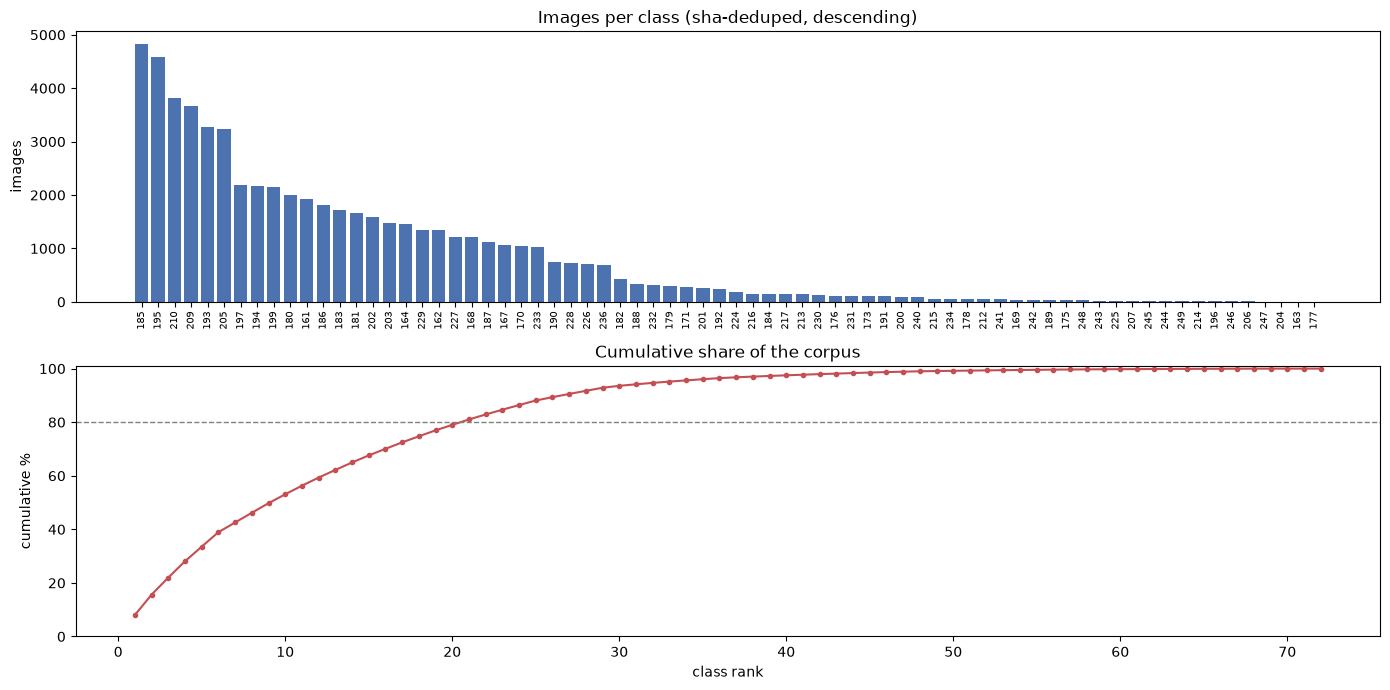

In [10]:
o = classes.sort_values("n_images_dedup", ascending=False)
fig, ax = plt.subplots(2, 1, figsize=(14, 7))
ax[0].bar(o.class_folder.astype(str), o.n_images_dedup, color="#4C72B0")
ax[0].set(title="Images per class (sha-deduped, descending)", ylabel="images")
ax[0].tick_params(axis="x", rotation=90, labelsize=7)
cumshare = o.n_images_dedup.cumsum() / o.n_images_dedup.sum() * 100
ax[1].plot(range(1, len(o) + 1), cumshare, marker="o", ms=3, color="#C44E52")
ax[1].axhline(80, ls="--", c="gray", lw=1)
ax[1].set(title="Cumulative share of the corpus", xlabel="class rank", ylabel="cumulative %",
          ylim=(0, 101))
plt.tight_layout()
plt.show()

## 8 · Geometry & intensity distributions

**What:** how big the images are, what shape, and how bright.

**Why:** these determine the input pipeline — whether a resize is mandatory, what target size is
reasonable, and whether polarity is consistent across the corpus.

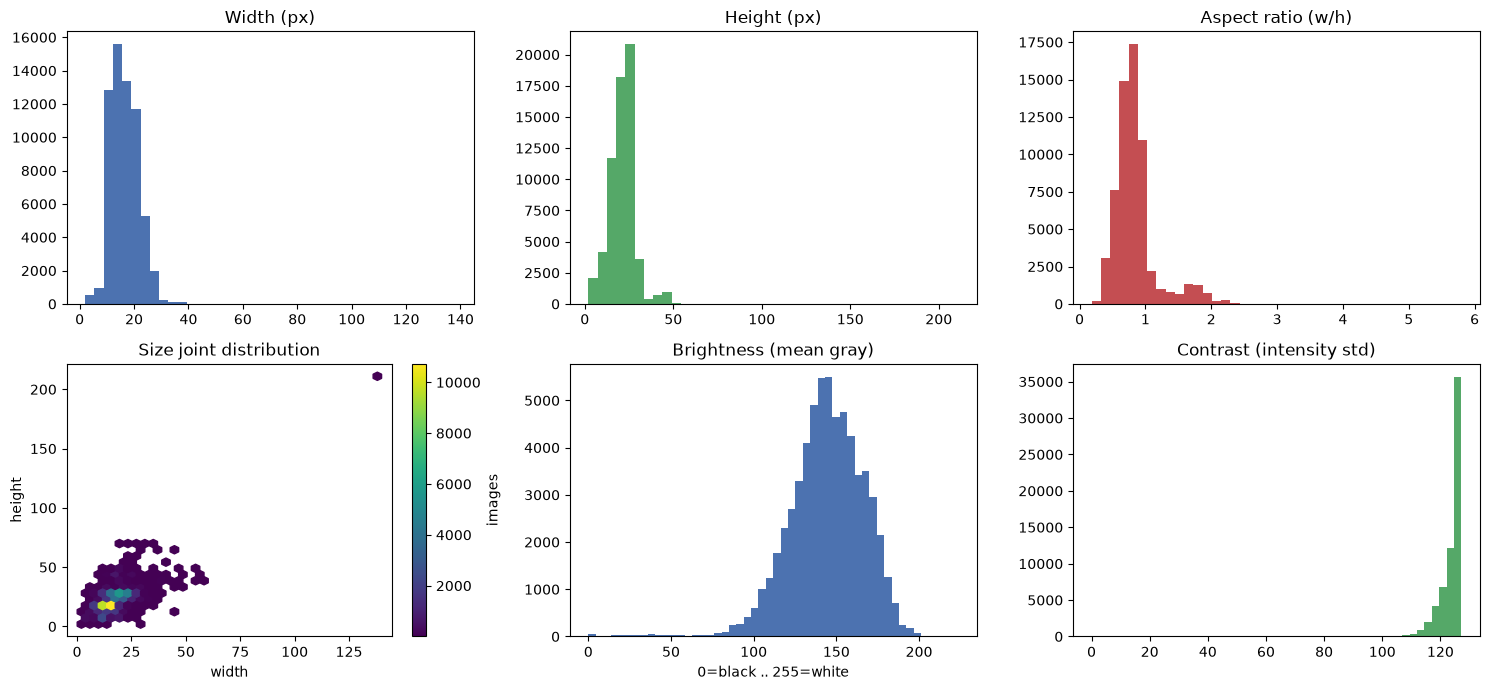

distinct (w,h) sizes : 988
most common          : 14x18 (3.3% of images)
width  range         : 2-138 px
height range         : 2-211 px
colour modes         : {'L': 62707}
global mean brightness: 144.1 / 255


In [11]:
fig, ax = plt.subplots(2, 3, figsize=(15, 7))
ax[0, 0].hist(readable.width, bins=40, color="#4C72B0")
ax[0, 0].set(title="Width (px)")
ax[0, 1].hist(readable.height, bins=40, color="#55A868")
ax[0, 1].set(title="Height (px)")
ax[0, 2].hist(readable.aspect_ratio, bins=40, color="#C44E52")
ax[0, 2].set(title="Aspect ratio (w/h)")
hb = ax[1, 0].hexbin(readable.width, readable.height, gridsize=35, cmap="viridis", mincnt=1)
ax[1, 0].set(title="Size joint distribution", xlabel="width", ylabel="height")
fig.colorbar(hb, ax=ax[1, 0], label="images")
ax[1, 1].hist(readable.mean_intensity, bins=50, color="#4C72B0")
ax[1, 1].set(title="Brightness (mean gray)", xlabel="0=black .. 255=white")
ax[1, 2].hist(readable.std_intensity, bins=50, color="#55A868")
ax[1, 2].set(title="Contrast (intensity std)")
plt.tight_layout()
plt.show()

sizes = readable.groupby(["width", "height"]).size().sort_values(ascending=False)
print(f"distinct (w,h) sizes : {len(sizes):,}")
print(f"most common          : {sizes.index[0][0]}x{sizes.index[0][1]} "
      f"({sizes.iloc[0]/len(readable)*100:.1f}% of images)")
print(f"width  range         : {int(readable.width.min())}-{int(readable.width.max())} px")
print(f"height range         : {int(readable.height.min())}-{int(readable.height.max())} px")
print(f"colour modes         : {readable['mode'].value_counts().to_dict()}")
print(f"global mean brightness: {readable.mean_intensity.mean():.1f} / 255")

## 9 · Outliers

**What:** three independent flags, unioned into one queue.

- Width, height, aspect, file size and brightness, scored by **robust z-score computed within each
  class** (median / MAD, not dragged around by the outliers it is looking for). Per-class, not
  pooled across the whole corpus — a class whose own geometry is legitimately unusual (ฤ/ป/ไ/ใ's
  long tails, a mark's own aspect ratio) is judged against itself, not against classes it was never
  meant to resemble.
- `degenerate_crop` — ink covers at least `DEGENERATE_INK_RATIO` of the image. An absolute floor,
  not a z-score: a crop this saturated with ink (in the extreme, a uniform black square with no
  variation at all) has trimmed away its own glyph shape, regardless of what the rest of its class
  looks like.
- `possible_contamination` — `n_ink_components >= CONTAMINATION_COMPONENTS` after filtering scan
  speckle. A single glyph should be one connected shape; two or more sizeable, separate ink blobs is
  what a neighbouring character's stroke leaking into the crop looks like.

**What this does not claim:** an outlier is *unusual*, not *wrong* — that still holds for the
z-score reasons. The two ink-based reasons are a stronger claim (the crop itself looks broken), but
still only a candidate list. Nothing here is auto-removed; everything is queued for a human to look
at in Marimo — §7 of that notebook.

> Per-class baselines here use the corrected `class_folder` from §6b, not the raw folder label, and skip images a `drop` ruling excluded.


In [12]:
METRICS = ["width", "height", "aspect_ratio", "size_bytes", "mean_intensity"]
Z_THRESHOLD = 3.5
DEGENERATE_INK_RATIO = 0.90     # ink covering >=90% of the crop leaves no legible glyph shape
CONTAMINATION_COMPONENTS = 2    # 2+ sizeable ink blobs suggests more than one glyph in the crop

def robust_z(x: pd.Series) -> np.ndarray:
    v = x.to_numpy(float)
    med = np.median(v)
    mad = np.median(np.abs(v - med))
    return np.zeros(len(v)) if mad == 0 else 0.6745 * (v - med) / mad

# Per-class, not pooled (see §9 above) -- and per §6b's corrected class_folder, not the raw
# folder label, so a reassigned image is judged against the class it actually belongs to.
# Drop-ruled images take no part in a baseline they're no longer trusted to represent.
stats_base = readable[~readable.excluded_by_ruling]
Z = stats_base.groupby("class_folder")[METRICS].transform(robust_z)
flagged = Z.abs().gt(Z_THRESHOLD)

degenerate   = stats_base.ink_ratio.ge(DEGENERATE_INK_RATIO)
contaminated = stats_base.n_ink_components.ge(CONTAMINATION_COMPONENTS)
is_outlier   = flagged.any(axis=1) | degenerate | contaminated

outliers = stats_base.loc[is_outlier, ["path", "class_folder", "raw_class_folder", "width",
                                       "height", "size_bytes", "mean_intensity", "ink_ratio",
                                       "n_ink_components"]].copy()

def _reasons(i: int) -> str:
    rs = [f"{m}(z={Z.loc[i, m]:+.1f})" for m in METRICS if flagged.loc[i, m]]
    if degenerate.loc[i]:
        rs.append(f"degenerate_crop(ink={stats_base.loc[i, 'ink_ratio']:.4f})")
    if contaminated.loc[i]:
        rs.append(f"possible_contamination(components={int(stats_base.loc[i, 'n_ink_components'])})")
    return "; ".join(rs)

outliers["reasons"] = [_reasons(i) for i in outliers.index]
outliers = outliers.sort_values("class_folder").reset_index(drop=True)

n_excluded_from_stats = int(readable.excluded_by_ruling.sum())
print(f"outliers: {len(outliers):,} ({len(outliers)/len(stats_base)*100:.2f}% of the "
      f"{len(stats_base):,} images eligible after §6b's corrections; "
      f"{n_excluded_from_stats} excluded by a drop ruling)")
print(flagged.sum().sort_values(ascending=False).to_string())
print(f"degenerate_crop          {int(degenerate.sum()):,}")
print(f"possible_contamination   {int(contaminated.sum()):,}")
outliers.head(10)


outliers: 7,445 (11.91% of the 62,523 images eligible after §6b's corrections; 184 excluded by a drop ruling)
aspect_ratio      3839
size_bytes        1984
mean_intensity     954
height             239
width              210
degenerate_crop          174
possible_contamination   731


,path,class_folder,raw_class_folder,width,height,size_bytes,mean_intensity,ink_ratio,n_ink_components,reasons
0,161/bc_004tg_5_23.jpg,161,161,24,30,874,82.283333,0.677778,1,mean_intensity(z=-4.6)
1,161/bc_004tg_5_36.jpg,161,161,24,30,925,89.637500,0.648611,1,mean_intensity(z=-4.1)
2,161/bc_005tg_4_447.jpg,161,161,19,26,973,134.172065,0.473684,2,possible_contamination(components=2)
3,161/bc_015sg_5_0.jpg,161,161,15,18,638,96.388889,0.622222,1,mean_intensity(z=-3.6)
4,161/bc_015tg_5_0.jpg,161,161,21,28,1013,93.801020,0.632653,1,mean_intensity(z=-3.8)
5,161/bc_020sg_4_454.jpg,161,161,8,16,465,139.445312,0.453125,1,aspect_ratio(z=-4.1)
6,161/bc_020sg_4_464.jpg,161,161,13,16,618,146.961538,0.423077,2,possible_contamination(components=2)
7,161/bc_020sg_4_92.jpg,161,161,10,16,594,157.593750,0.381250,2,possible_contamination(components=2)
8,161/bc_020tg_4_121.jpg,161,161,14,24,696,167.598214,0.342262,2,possible_contamination(components=2)
9,161/bc_020tg_4_146.jpg,161,161,20,25,838,157.644000,0.382000,2,possible_contamination(components=2)


### 9a · Outliers by class

Now that flagging is per-class (§9), it's worth seeing whether that redistributed the flags
sensibly rather than just moving the problem around. Both panels are the same stack — flag counts
per reason, then that same breakdown normalized by class size — so a class's overall exposure and
which reason drives it stay visible together. A class can appear in more than one reason's slice
since a single image can trip more than one flag, which is also why a stack can run past the
dashed any-reason rate line.

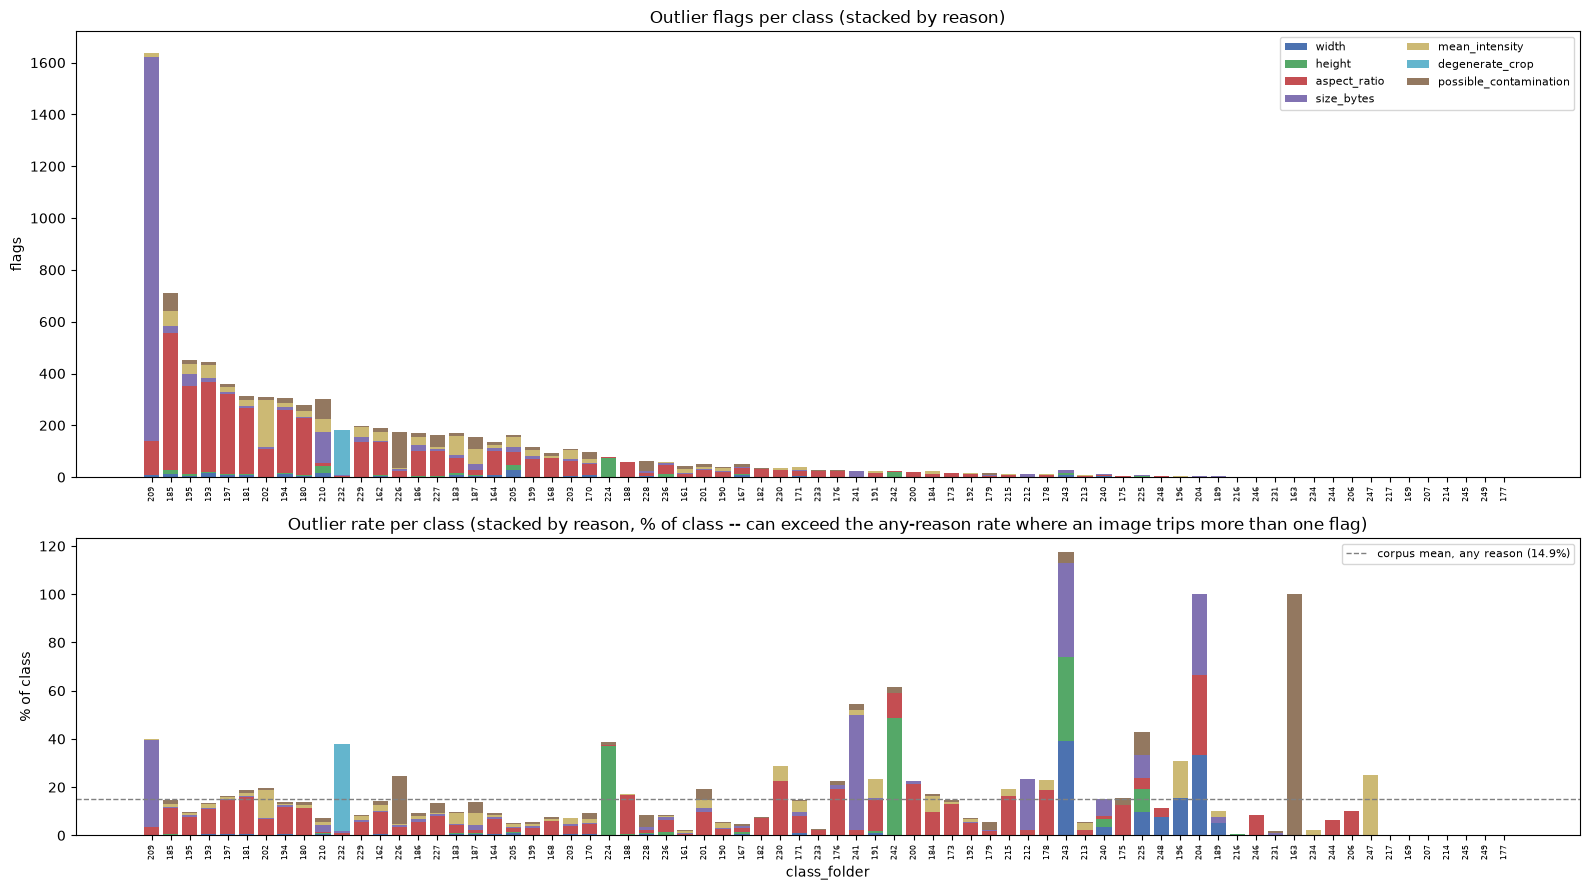

classes with zero outliers: 7 / 72

top 15 classes by outlier count:
              width  height  aspect_ratio  size_bytes  mean_intensity  degenerate_crop  possible_contamination  total_flags  n_images  rate_pct
class_folder                                                                                                                                   
209               8       0           132        1480              18                0                       1         1639      4082      39.7
185              13      15           528          26              58                0                      70          710      4870      13.3
195               5       7           341          45              39                0                      14          451      4665       9.3
193              17       3           347          14              51                0                      13          445      3308      12.6
197               9       4           307           9              

In [13]:
n_per_class = stats_base.class_folder.value_counts()

per_class_reasons = (
    flagged.astype(int)
    .assign(degenerate_crop=degenerate.astype(int),
            possible_contamination=contaminated.astype(int),
            class_folder=stats_base.class_folder.to_numpy())
    .groupby("class_folder").sum()
    .reindex(n_per_class.index, fill_value=0)
)
n_outliers_per_class = outliers.class_folder.value_counts().reindex(n_per_class.index, fill_value=0)
outlier_rate = n_outliers_per_class / n_per_class * 100
rate_by_reason = per_class_reasons.div(n_per_class, axis=0) * 100
order = n_outliers_per_class.sort_values(ascending=False).index

REASON_COLORS = {
    "width": "#4C72B0", "height": "#55A868", "aspect_ratio": "#C44E52",
    "size_bytes": "#8172B2", "mean_intensity": "#CCB974",
    "degenerate_crop": "#64B5CD", "possible_contamination": "#937860",
}

fig, ax = plt.subplots(2, 1, figsize=(16, 9), height_ratios=[3, 2])
bottom = np.zeros(len(order))
for reason, color in REASON_COLORS.items():
    vals = per_class_reasons.loc[order, reason].to_numpy()
    ax[0].bar(order.astype(str), vals, bottom=bottom, label=reason, color=color)
    bottom += vals
ax[0].set(title="Outlier flags per class (stacked by reason)", ylabel="flags")
ax[0].tick_params(axis="x", rotation=90, labelsize=6)
ax[0].legend(loc="upper right", fontsize=8, ncol=2)

# same stack, normalized by class size and by reason, so both a class's overall exposure and
# which reason drives it are visible together -- a flat sum() bar (like the earlier version of
# this cell) hides exactly that breakdown.
bottom = np.zeros(len(order))
for reason, color in REASON_COLORS.items():
    vals = rate_by_reason.loc[order, reason].to_numpy()
    ax[1].bar(order.astype(str), vals, bottom=bottom, color=color)
    bottom += vals
ax[1].axhline(outlier_rate.mean(), ls="--", c="gray", lw=1,
              label=f"corpus mean, any reason ({outlier_rate.mean():.1f}%)")
ax[1].set(title="Outlier rate per class (stacked by reason, % of class -- can exceed the "
                 "any-reason rate where an image trips more than one flag)",
          ylabel="% of class", xlabel="class_folder")
ax[1].tick_params(axis="x", rotation=90, labelsize=6)
ax[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

print(f"classes with zero outliers: {int((n_outliers_per_class == 0).sum())} / {len(n_per_class)}")
print("\ntop 15 classes by outlier count:")
print(per_class_reasons.assign(total_flags=per_class_reasons.sum(axis=1),
                               n_images=n_per_class, rate_pct=outlier_rate.round(1))
      .sort_values("total_flags", ascending=False).head(15).to_string())

## 10 · Near-duplicate candidates — computed, not thresholded

Exact duplicates were settled in §6. What remains is *near* duplicates: images that are not
byte-identical but may still be the same sample, which would leak across a train/validation split.

Deciding "how near is the same" requires looking at glyphs, so **no threshold is chosen here**. This
section computes both candidate signals **exhaustively** and reports their full distributions;
Marimo does the cutting.

Both sweeps are complete — every one of the 1.97 billion pairs is evaluated. The prior pipeline used
LSH banding with a `bucket_cap` that silently discarded pairs inside over-large buckets; measured on
this machine that approximation saves seconds and is not worth the blind spot.

### 10a · pHash multiplicity — degeneracy made visible

**What:** how many images share each distinct pHash value.

**Why:** a hash shared by thousands of images is degenerate — it carries no information and makes
pair counts explode as *n²/2*. The prior pipeline handled this with a `degenerate_folder_span = 5`
constant that excluded such hashes before anyone saw them. Here the distribution is printed instead,
so the problem is observable rather than assumed.

In [14]:
mult = readable.phash.value_counts()
print(f"distinct phash values          : {len(mult):,}  (over {len(readable):,} images)")
print(f"values shared by >1 image      : {int((mult > 1).sum()):,}")
print(f"images sharing a phash         : {int(mult[mult > 1].sum()):,}")
print(f"largest multiplicities         : {mult.head(8).tolist()}")
print(f"pairs implied by collisions    : {int((mult[mult>1] * (mult[mult>1]-1) // 2).sum()):,}")

zero_hash = int((readable.phash == "0" * 16).sum())
print(f"all-zero (degenerate) hashes   : {zero_hash:,}")

distinct phash values          : 54,215  (over 62,707 images)
values shared by >1 image      : 4,005
images sharing a phash         : 12,497
largest multiplicities         : [88, 71, 61, 58, 58, 51, 50, 43]
pairs implied by collisions    : 40,225
all-zero (degenerate) hashes   : 58


### 10b · What a pHash threshold of 1 actually buys

pHash sets each bit by comparing a DCT coefficient to the **median** of the 64 low-frequency
coefficients. When no coefficient ties the median, that splits 64 values exactly in half and the
hash carries **exactly 32 set bits** — and two integers with equal popcount always differ in an
**even** number of bits.

So for the overwhelming majority of this corpus, pHash distances can only be even, and a threshold
of 1 accepts precisely what a threshold of 0 accepts. The exceptions are the handful of tiny glyphs
where coefficients do tie (see §4); those carry fewer set bits and can sit an odd distance from
everything else.

That matters for reading the prior work: `Data_Preparation.ipynb` used
`phash_hamming_threshold = 1` as its near-duplicate rule. The cell below measures the count of pairs
at distance *exactly 1* rather than arguing from the invariant — if it is zero, that threshold
merged nothing that a threshold of 0 would not have merged, and the rule was inert.

In [15]:
h = readable.phash.apply(lambda x: int(x, 16)).to_numpy(np.uint64)
popcount = np.bitwise_count(h)
print("set-bits per hash (a clean median split gives 32):")
for _bits, _n in zip(*np.unique(popcount, return_counts=True), strict=True):
    print(f"   {_bits:2} bits : {_n:,} images")

t0 = time.time()
N = len(h)
phash_hist = np.zeros(65, np.int64)          # int64: counts here reach ~2e9
ph_i, ph_j, ph_d = [], [], []                # candidate pairs, collected in the same pass
BLK = 2048
for s in range(0, N, BLK):
    d = np.bitwise_count(h[s:s + BLK, None] ^ h[None, :]).astype(np.uint8)
    upper = np.arange(N)[None, :] > (s + np.arange(d.shape[0]))[:, None]
    phash_hist += np.bincount(d[upper], minlength=65)
    r, c = np.nonzero((d <= PHASH_PAIR_CUT) & upper)
    ph_i.append((r + s).astype(np.int32))
    ph_j.append(c.astype(np.int32))
    ph_d.append(d[r, c].astype(np.uint8))
TIMINGS["phash_sweep_s"] = round(time.time() - t0, 1)

print(f"\nexhaustive sweep over {N*(N-1)//2:,} pairs in {TIMINGS['phash_sweep_s']}s")
print(f"pairs at an odd Hamming distance : {int(phash_hist[1::2].sum()):,}"
      f"   (only possible via the tied-coefficient hashes above)")
print(f"pairs at distance exactly 1      : {int(phash_hist[1]):,}")
print(f"-> a threshold of 1 merges {int(phash_hist[1]):,} pair(s) beyond a threshold of 0.")
print("\ncumulative pairs by Hamming distance:")
for t in range(0, 9, 2):
    print(f"  d <= {t}: {int(phash_hist[:t+1].sum()):>12,}")
check("phash sweep total reconciles", int(phash_hist.sum()) == N * (N - 1) // 2)

set-bits per hash (a clean median split gives 32):
    0 bits : 58 images
   15 bits : 1 images
   16 bits : 3 images
   20 bits : 1 images
   32 bits : 62,644 images



exhaustive sweep over 1,966,052,571 pairs in 31.8s
pairs at an odd Hamming distance : 62,706   (only possible via the tied-coefficient hashes above)
pairs at distance exactly 1      : 0
-> a threshold of 1 merges 0 pair(s) beyond a threshold of 0.

cumulative pairs by Hamming distance:
  d <= 0:       40,225
  d <= 2:      322,203
  d <= 4:    1,499,407
  d <= 6:    4,267,137
  d <= 8:    8,848,435
  [PASS] phash sweep total reconciles


### 10c · Pixel distance

**What:** RMS gray-level difference between images letterboxed (scale-to-fit, aspect preserved,
padded white) onto a common 16×16 grid, in units of gray levels (0–255). An RMS of 4 means the
two images differ by 4 gray levels per pixel on average.

**Why a second signal:** pHash on 12×18 crops is questionable — it upscales to 32×32 before the
DCT, so it summarises frequency content the source never had. Direct pixel comparison measures
what we actually care about, and §10b showed pHash can only move in steps of 2 bits, which is
coarse.

Exhaustive over all pairs, on GPU when available. Only the near-duplicate tail is histogrammed at
full resolution; the bulk is a single count. That keeps the accumulation in exact int64 — a float32
histogram cannot represent counts above 2²⁴ and silently loses them.

In [16]:
try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except ImportError:
    torch, DEVICE = None, None

TAIL_HI, TAIL_SCALE = 64.0, 4        # histogram rms<=64 at 0.25 resolution
assert torch is not None, "torch is required for the pixel sweep"

X  = torch.from_numpy(pixels).to(DEVICE)
sq = (X * X).sum(1)
D  = pixels.shape[1]
pixel_hist = np.zeros(int(TAIL_HI * TAIL_SCALE) + 1, np.int64)
pix_i, pix_j, pix_d = [], [], []
n_at_cut = 0                    # exact count at PIXEL_PAIR_CUT, to tie the table out
t0 = time.time()
for s in range(0, N, BLK):
    d2  = sq[s:s + BLK, None] + sq[None, :] - 2.0 * (X[s:s + BLK] @ X.T)
    rms = (d2.clamp_min_(0) / D).sqrt_()
    cols = torch.arange(N, device=DEVICE)
    rms[cols[None, :] <= (s + torch.arange(rms.shape[0], device=DEVICE))[:, None]] = float("inf")
    tail = rms[rms <= TAIL_HI]
    # floor, not round: bin k covers [k/scale, (k+1)/scale) so cumulative sums are exact
    pixel_hist += np.bincount((tail * TAIL_SCALE).floor().to(torch.int64).cpu().numpy(),
                              minlength=len(pixel_hist))[:len(pixel_hist)]
    n_at_cut += int((rms <= PIXEL_PAIR_CUT).sum())
    r, c = torch.nonzero(rms <= PIXEL_PAIR_CUT, as_tuple=True)
    pix_i.append((r + s).cpu().numpy().astype(np.int32))
    pix_j.append(c.cpu().numpy().astype(np.int32))
    pix_d.append(rms[r, c].cpu().numpy().astype(np.float32))
    del d2, rms, tail
TIMINGS["pixel_sweep_s"] = round(time.time() - t0, 1)

print(f"exhaustive sweep on {DEVICE} in {TIMINGS['pixel_sweep_s']}s")
print(f"total pairs {N*(N-1)//2:,} | tail (rms <= {TAIL_HI:g}) {pixel_hist.sum():,}\n")
print("cumulative pairs by RMS gray distance:")
for t in (1, 2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64):
    print(f"  rms <  {t:>2}: {int(pixel_hist[:int(t*TAIL_SCALE)].sum()):>12,}")
print(f"\nexactly at the storage cut (rms <= {PIXEL_PAIR_CUT:g}): {n_at_cut:,}")

exhaustive sweep on cuda in 1.7s
total pairs 1,966,052,571 | tail (rms <= 64) 29,952,955

cumulative pairs by RMS gray distance:
  rms <   1:       16,425
  rms <   2:       16,433
  rms <   3:       16,776
  rms <   4:       18,241
  rms <   6:       27,691
  rms <   8:       57,670
  rms <  12:      203,301
  rms <  16:      548,267
  rms <  24:    1,974,281
  rms <  32:    4,813,317
  rms <  48:   14,974,130
  rms <  64:   29,952,877

exactly at the storage cut (rms <= 32): 4,813,351


### 10d · What the two signals see

Plotting both as "how many pairs would be merged at this cut" puts them on comparable footing. The
pixel curve is flat from 0 to ~4 and then climbs — that plateau is a population of pairs separated
from everything else by a gap, which is the shape a real duplicate population has. pHash moves in
jumps of two bits and cannot resolve that region.

Read this as evidence for the Marimo tuning step, not as a decision.

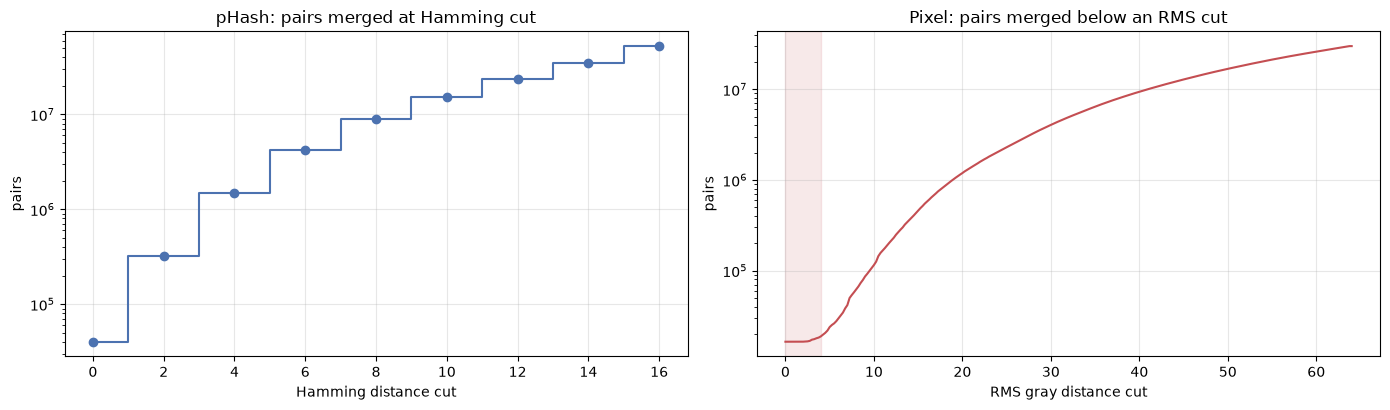

pixel pairs at rms <  4 : 18,241  (the plateau)
phash pairs at d == 0   : 40,225
the two populations are not the same size -- section 4 of the Marimo notebook compares them pair by pair.


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
d_ax = np.arange(0, 17, 2)
ax[0].step(d_ax, [phash_hist[:t+1].sum() for t in d_ax], where="mid", color="#4C72B0", marker="o")
ax[0].set(title="pHash: pairs merged at Hamming cut", xlabel="Hamming distance cut",
          ylabel="pairs", yscale="log", xticks=d_ax)
r_ax = np.arange(0, TAIL_HI * TAIL_SCALE + 1) / TAIL_SCALE
ax[1].plot(r_ax, np.cumsum(pixel_hist), color="#C44E52")
ax[1].set(title="Pixel: pairs merged below an RMS cut", xlabel="RMS gray distance cut",
          ylabel="pairs", yscale="log")
ax[1].axvspan(0, 4, color="#C44E52", alpha=0.12)
for a in ax:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"pixel pairs at rms <  4 : {int(pixel_hist[:4*TAIL_SCALE].sum()):,}  (the plateau)")
print(f"phash pairs at d == 0   : {int(phash_hist[0]):,}")
print("the two populations are not the same size -- section 4 of the Marimo notebook compares them pair by pair.")

### 10e · Write the candidate tables

Pairs are stored as **row indices into `images.csv`**, which is compact and unambiguous given the
manifest's fixed sort order. The cuts below bound file size only; both tables regenerate from
scratch in well under a minute.

In [18]:
# both candidate sets were collected during their sweeps above; assemble and write
t0 = time.time()
pairs_phash = pd.DataFrame({"i": np.concatenate(ph_i), "j": np.concatenate(ph_j),
                            "hamming": np.concatenate(ph_d)})
pairs_pixel = pd.DataFrame({"i": np.concatenate(pix_i), "j": np.concatenate(pix_j),
                            "rms": np.concatenate(pix_d).round(3)}).sort_values(["i", "j"])

for name, df in (("pairs_phash", pairs_phash), ("pairs_pixel", pairs_pixel)):
    p = MANIFEST / "pairs" / f"{name}.csv.gz"
    df.to_csv(p, index=False, compression="gzip")
    print(f"{name:12} {len(df):>9,} rows   {p.stat().st_size/1e6:6.1f} MB   -> {p.relative_to(ROOT)}")
TIMINGS["pair_tables_s"] = round(time.time() - t0, 1)

pd.DataFrame({"hamming": np.arange(65), "pairs": phash_hist}).query("pairs > 0").to_csv(
    MANIFEST / "dist_phash.csv", index=False)
pd.DataFrame({"rms_bin_lo": np.arange(len(pixel_hist)) / TAIL_SCALE,
              "rms_bin_hi": (np.arange(len(pixel_hist)) + 1) / TAIL_SCALE,
              "pairs": pixel_hist}).to_csv(MANIFEST / "dist_pixel.csv", index=False)
print("\nfull distributions -> dist_phash.csv, dist_pixel.csv")

pairs_phash  1,499,407 rows      4.1 MB   -> data/baseline/manifest/pairs/pairs_phash.csv.gz


pairs_pixel  4,813,351 rows     24.1 MB   -> data/baseline/manifest/pairs/pairs_pixel.csv.gz

full distributions -> dist_phash.csv, dist_pixel.csv


### 10f · Near-duplicate groups — applying a recorded decision

**What:** join images into leakage groups. Exact duplicates (§6) are always joined; on top of that,
every pixel pair at or under the RMS threshold recorded in `configs/near_dup.json` is joined. Groups
are connected components, so membership is transitive: A~B and B~C put A, B and C together.

**Why here, when this notebook chooses no thresholds:** it still doesn't. The threshold is a human
decision made in `02_visual_check.py` §4 and read back from `configs/`; applying it is arithmetic.
Without the config file, groups fall back to exact duplicates only.

**What this does not claim:** nothing is dropped. A group is a constraint for the split — it must land
wholly inside one split — not a verdict that its members are the same sample. `near_dup_group_id` is
the lowest `sha_group_id` among the members, so an ungrouped image keeps its own SHA group id.

The remaining cross-class groups go to `findings_cross_class_near.csv`, one row per image. SHA
groups that already span classes are handled exclusively by `findings_cross_class_exact.csv`; the
near queue contains only distinct images and is adjudicated per image, not per group.

In [19]:
near_dup_cfg = CONFIGS / "near_dup.json"
if near_dup_cfg.exists():
    near_dup = json.loads(near_dup_cfg.read_text())
    assert near_dup["signal"] == "rms", f"unsupported near-dup signal {near_dup['signal']!r}"
    NEAR_DUP_RMS = float(near_dup["threshold"])
    assert NEAR_DUP_RMS <= PIXEL_PAIR_CUT, "threshold exceeds what the pair table keeps"
    print(f"near-dup rule from {near_dup_cfg.relative_to(ROOT)}: rms <= {NEAR_DUP_RMS:g}")
else:
    NEAR_DUP_RMS = None
    print(f"{near_dup_cfg.relative_to(ROOT)} not found -> grouping exact duplicates only")

# union-find over scan rows. Pixel pairs index scan rows; unreadable rows hold an all-zero vector
# and would match each other, so only readable rows take part.
parent = np.arange(len(scan))

def find(a: int) -> int:
    while parent[a] != a:
        parent[a] = parent[parent[a]]
        a = parent[a]
    return a

def union(a: int, b: int) -> None:
    ra, rb = find(a), find(b)
    if ra != rb:
        parent[max(ra, rb)] = min(ra, rb)

ok = scan.readable.to_numpy(bool)
for rows in scan[ok].groupby("sha256").indices.values():
    for r in scan.index[ok][rows[1:]]:
        union(int(scan.index[ok][rows[0]]), int(r))
edges = (pairs_pixel[pairs_pixel.rms <= NEAR_DUP_RMS] if NEAR_DUP_RMS is not None
         else pairs_pixel.iloc[:0])
edges = edges[ok[edges.i.to_numpy()] & ok[edges.j.to_numpy()]]
for a, b in zip(edges.i.to_numpy(), edges.j.to_numpy(), strict=True):
    union(int(a), int(b))
n_nd_edges = len(edges)

root = pd.Series([find(i) for i in range(len(scan))], index=scan.index).where(ok)
scan["near_dup_group_id"] = scan.groupby(root).sha_group_id.transform("min").astype("Int64")
gnd = scan.groupby("near_dup_group_id")
scan["near_dup_group_size"] = gnd.path.transform("size").astype("Int64")
scan["near_dup_group_spans_classes"] = (gnd.class_folder.transform("nunique") > 1).fillna(False)
readable_nd = scan[ok]

cross_near = (scan[scan.near_dup_group_spans_classes]
              .sort_values(["near_dup_group_id", "path"])
              [["near_dup_group_id", "path", "class_folder", "sha_group_id",
                "sha_group_spans_classes", "near_dup_group_size"]]
              .reset_index(drop=True))
_g = cross_near.groupby("near_dup_group_id")
cross_near["classes_in_group"] = cross_near.near_dup_group_id.map(
    _g.class_folder.apply(lambda s: ",".join(map(str, sorted(s.unique())))))
cross_near["n_distinct_sha"] = cross_near.near_dup_group_id.map(_g.sha_group_id.nunique())
# Exact cross-class SHA groups already have a group-level adjudication queue. Keep this queue
# for the remaining, genuinely near-only images so the two review workflows never overlap.
cross_near = cross_near[~cross_near.sha_group_spans_classes].reset_index(drop=True)

sizes = readable_nd.groupby("near_dup_group_id").size()
n_nd_groups = len(sizes)
print(f"edges joined (rms <= threshold) : {n_nd_edges:,}")
print(f"near-dup groups                 : {n_nd_groups:,}  (vs {scan.sha256.nunique():,} sha groups)")
print(f"  with more than one image      : {int((sizes > 1).sum()):,}")
print(f"  largest                       : {int(sizes.max())} images")
print(f"  cross-class near-only queue    : {cross_near.near_dup_group_id.nunique()}"
      f"  ({len(cross_near)} images)")
print()
print(cross_near.groupby("near_dup_group_id")
      .agg(images=("path", "size"), distinct_sha=("n_distinct_sha", "first"),
           classes=("classes_in_group", "first"), has_exact_cross=("sha_group_spans_classes", "any"))
      .to_string())

near-dup rule from configs/near_dup.json: rms <= 4


edges joined (rms <= threshold) : 18,242
near-dup groups                 : 59,650  (vs 60,128 sha groups)
  with more than one image      : 1,274
  largest                       : 88 images
  cross-class near-only queue    : 3  (43 images)

                   images  distinct_sha  classes  has_exact_cross
near_dup_group_id                                                
957                    28            14  210,229            False
6111                    9             7  210,229            False
18293                   6             6  210,229            False


## 11 · Write the manifest

`images.csv` is the canonical per-image index. `path` is relative to `raw/`, so the manifest is
portable. Row order is sorted by `path` and is what the pair tables index into.

In [20]:
IMAGE_COLS = ["path", "class_folder", "file_name", "size_bytes", "readable", "error",
              "width", "height", "mode", "channels", "aspect_ratio",
              "mean_intensity", "std_intensity", "min_intensity", "max_intensity",
              "ink_ratio", "n_ink_components",
              "sha256", "phash", "sha_group_id", "sha_group_size", "is_sha_canonical",
              "sha_group_spans_classes", "near_dup_group_id", "near_dup_group_size",
              "near_dup_group_spans_classes",
              "raw_class_folder", "excluded_by_ruling"]

images = scan.sort_values("path").reset_index(drop=True)[IMAGE_COLS]
for c in ["aspect_ratio", "mean_intensity", "std_intensity", "ink_ratio"]:
    images[c] = images[c].round(4)

geom = readable.groupby("class_folder").agg(
    width_min=("width", "min"), width_max=("width", "max"), width_mean=("width", "mean"),
    height_min=("height", "min"), height_max=("height", "max"), height_mean=("height", "mean"),
    brightness_mean=("mean_intensity", "mean"), contrast_mean=("std_intensity", "mean"),
    ink_ratio_mean=("ink_ratio", "mean"))
classes_out = classes.merge(geom.round(2), on="class_folder", how="left")

images.to_csv(MANIFEST / "images.csv", index=False)
classes_out.to_csv(MANIFEST / "classes.csv", index=False)
non_images.to_csv(MANIFEST / "non_images.csv", index=False)
cross.to_csv(MANIFEST / "findings_cross_class_exact.csv", index=False)
cross_near.to_csv(MANIFEST / "findings_cross_class_near.csv", index=False)
outliers.to_csv(MANIFEST / "findings_outliers.csv", index=False)
folder_inventory.to_csv(MANIFEST / "folder_inventory.csv", index=False)

for f in sorted(MANIFEST.rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to(MANIFEST).as_posix():38} {f.stat().st_size/1e6:7.2f} MB")

  classes.csv                               0.00 MB
  dist_phash.csv                            0.00 MB
  dist_pixel.csv                            0.00 MB
  findings_cross_class_exact.csv            0.00 MB
  findings_cross_class_near.csv             0.00 MB
  findings_outliers.csv                     0.76 MB
  folder_inventory.csv                      0.00 MB
  images.csv                               14.36 MB
  non_images.csv                            0.00 MB
  pairs/pairs_phash.csv.gz                  4.14 MB
  pairs/pairs_pixel.csv.gz                 24.15 MB
  run.json                                  0.00 MB


## 12 · Self-check

**What:** assert that every number this notebook published ties out against every other.

**What this is not:** a verdict on the dataset. The prior pipeline ended on a `GREEN`/`RED` gate that
declared the data fit for training. This checks the notebook's own arithmetic — whether the dataset
is fit for anything is a question for the people looking at it.

In [21]:
check("class counts sum to image total",
      int(classes_out.n_images_raw.sum()) == len(readable),
      f"{int(classes_out.n_images_raw.sum()):,} == {len(readable):,}")
check("dedup counts reconcile",
      int(classes_out.n_images_dedup.sum()) == int(scan.is_sha_canonical.sum()))
check("redundant copies reconcile",
      int(classes_out.n_redundant_copies.sum()) == len(scan) - scan.sha256.nunique())
check("one canonical per sha group",
      int(scan.is_sha_canonical.sum()) == scan.sha256.nunique())
check("file inventory reconciles",
      len(images) + len(non_images) == n_files, f"{len(images):,} + {len(non_images)} == {n_files:,}")
check("manifest paths unique", images.path.is_unique)
check("pair indices in range",
      bool(pairs_phash[["i", "j"]].max().max() < len(images)
           and pairs_pixel[["i", "j"]].max().max() < len(images)))
check("phash pair table matches its sweep",
      len(pairs_phash) == int(phash_hist[:PHASH_PAIR_CUT + 1].sum()),
      f"{len(pairs_phash):,}")
check("pixel pair table matches its sweep", len(pairs_pixel) == n_at_cut, f"{n_at_cut:,}")
check("pair tables are upper-triangular",
      bool((pairs_phash.i < pairs_phash.j).all() and (pairs_pixel.i < pairs_pixel.j).all()))
check("cross-class findings match manifest flag",
      len(cross) == int(images.sha_group_spans_classes.sum()))
check("scan order is manifest order (pair indices mean the same rows)",
      bool((scan.path.to_numpy() == images.path.to_numpy()).all()))
check("near-dup groups partition the readable images",
      int(readable_nd.groupby("near_dup_group_id").size().sum()) == len(readable))
check("every sha group sits inside one near-dup group",
      int(readable_nd.groupby("sha_group_id").near_dup_group_id.nunique().max()) == 1)
check("near-dup group id is its lowest member sha group",
      bool((readable_nd.groupby("near_dup_group_id").sha_group_id.min()
            == readable_nd.groupby("near_dup_group_id").sha_group_id.min().index).all()))
check("cross-class near findings exclude exact-duplicate queue",
      (not cross_near.sha_group_spans_classes.any())
      and len(cross_near) == int((images.near_dup_group_spans_classes
                                  & ~images.sha_group_spans_classes).sum()))
check("raw/ untouched", raw_signature() == sig)

gate = pd.DataFrame(CHECKS)
run = dict(
    dataset=DATASET,
    generated_at=datetime.now(UTC).isoformat(timespec="seconds"),
    versions=dict(python=platform.python_version(), numpy=np.__version__,
                  pandas=pd.__version__, pillow=Image.__version__,
                  torch=(torch.__version__ if torch else None), device=DEVICE),
    config=dict(random_state=RANDOM_STATE, pixel_grid=PIXEL_GRID,
                phash_pair_cut=PHASH_PAIR_CUT, pixel_pair_cut=PIXEL_PAIR_CUT,
                outlier_z=Z_THRESHOLD, near_dup_rms_threshold=NEAR_DUP_RMS),
    counts=dict(files=n_files, images=len(images), non_images=len(non_images),
                classes=len(classes_out), distinct_sha256=int(scan.sha256.nunique()),
                redundant_copies=int(len(scan) - scan.sha256.nunique()),
                cross_class_dup_images=len(cross), outliers=len(outliers),
                pairs_phash=len(pairs_phash), pairs_pixel=len(pairs_pixel),
                near_dup_groups=n_nd_groups, near_dup_edges=n_nd_edges,
                cross_class_near_dup_groups=int(cross_near.near_dup_group_id.nunique()),
                cross_class_near_dup_images=len(cross_near)),
    timings_s=TIMINGS,
    checks={c["check"]: ("PASS" if c["passed"] else "FAIL") for c in CHECKS},
)
(MANIFEST / "run.json").write_text(json.dumps(run, indent=2))

n_ok = int(gate.passed.sum())
print(f"\n{n_ok}/{len(gate)} checks passed")
if n_ok != len(gate):
    display(gate[~gate.passed])
print("\nraw/ was read only. Manifest written to", MANIFEST.relative_to(ROOT))
print("Next: uv run marimo edit notebooks/02_visual_check.py")

  [PASS] class counts sum to image total  — 62,707 == 62,707
  [PASS] dedup counts reconcile
  [PASS] redundant copies reconcile
  [PASS] one canonical per sha group
  [PASS] file inventory reconciles  — 62,707 + 4 == 62,711
  [PASS] manifest paths unique
  [PASS] pair indices in range
  [PASS] phash pair table matches its sweep  — 1,499,407
  [PASS] pixel pair table matches its sweep  — 4,813,351
  [PASS] pair tables are upper-triangular
  [PASS] cross-class findings match manifest flag
  [PASS] scan order is manifest order (pair indices mean the same rows)
  [PASS] near-dup groups partition the readable images
  [PASS] every sha group sits inside one near-dup group
  [PASS] near-dup group id is its lowest member sha group
  [PASS] cross-class near findings exclude exact-duplicate queue
  [PASS] raw/ untouched



25/25 checks passed

raw/ was read only. Manifest written to data/baseline/manifest
Next: uv run marimo edit notebooks/02_visual_check.py
